<a href="https://colab.research.google.com/github/brightliam20-ops/AVCAD-ASSIGNMENT/blob/main/Assignment_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import zipfile
import os

zip_file_path = '/content/EFIplus_medit.zip'
extract_dir = '/content/EFIplus_medit_data'

# Create the extraction directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"Files extracted to: {extract_dir}")

# List the extracted files to identify the dataset
print("Extracted files:")
for root, dirs, files in os.walk(extract_dir):
    for name in files:
        print(os.path.join(root, name))

Files extracted to: /content/EFIplus_medit_data
Extracted files:
/content/EFIplus_medit_data/EFIplus_medit.csv


In [3]:
import pandas as pd

# Construct the full path to the CSV file
csv_file_path = os.path.join(extract_dir, 'EFIplus_medit.csv')

# Load the dataset into a pandas DataFrame, specifying the semicolon delimiter
df = pd.read_csv(csv_file_path, delimiter=';')

# Display the first 5 rows of the DataFrame
print("First 5 rows of the dataset:")
print(df.head())

# Display information about the DataFrame (columns, non-null counts, dtypes)
print("\nDataFrame Info:")
df.info()

First 5 rows of the dataset:
    Site_code   Latitude  Longitude Country Catchment_name  Galiza  Subsample  \
0  ES_01_0002  38.102003  -4.096070   Spain   Guadalquivir       0          1   
1  ES_02_0001  40.530188  -1.887796   Spain           Tejo       0          1   
2  ES_02_0002  40.595432  -1.928079   Spain           Tejo       0          1   
3  ES_02_0003  40.656184  -1.989831   Spain           Tejo       0          1   
4  ES_02_0004  40.676402  -2.036274   Spain           Tejo       0          1   

   Calib_EFI_Medit  Calib_connect  Calib_hydrol  ...  Squalius malacitanus  \
0                0              1             0  ...                     0   
1                1              1             1  ...                     0   
2                1              1             1  ...                     0   
3                1              1             1  ...                     0   
4                1              1             1  ...                     0   

   Squalius pyr

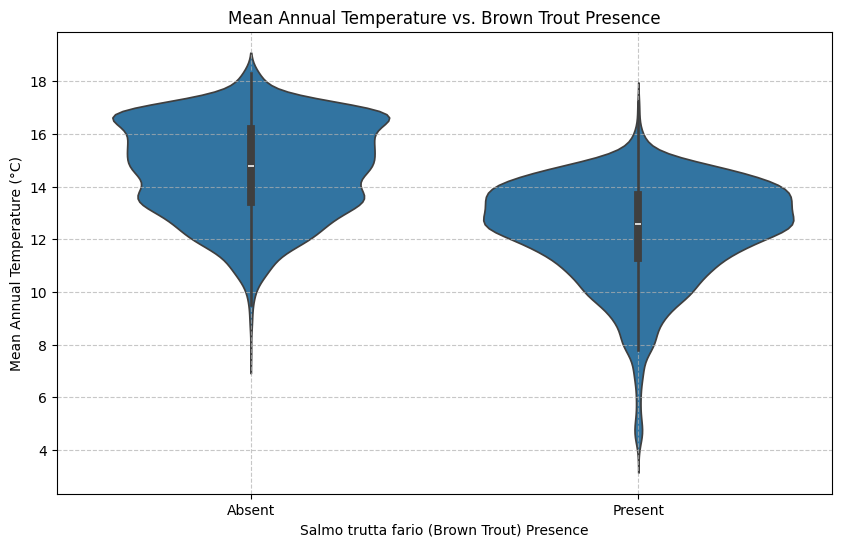

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Rename the column for easier plotting and understanding
df['Brown_Trout_Presence'] = df['Salmo trutta fario'].apply(lambda x: 'Present' if x == 1 else 'Absent')

plt.figure(figsize=(10, 6))
sns.violinplot(x='Brown_Trout_Presence', y='temp_ann', data=df)
plt.title('Mean Annual Temperature vs. Brown Trout Presence')
plt.xlabel('Salmo trutta fario (Brown Trout) Presence')
plt.ylabel('Mean Annual Temperature (°C)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

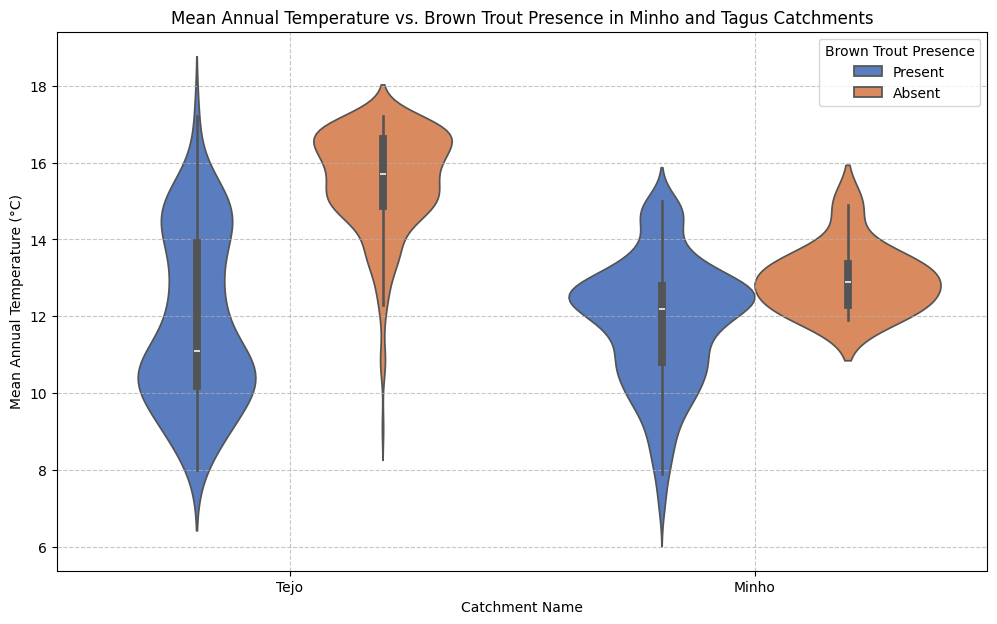


Mean Annual Temperatures by Catchment and Brown Trout Presence:
Brown_Trout_Presence     Absent    Present
Catchment_name                            
Minho                 12.963636  11.840948
Tejo                  15.511111  11.810651

Difference in Mean Annual Temperature (Absent - Present) by Catchment:
Catchment_name
Minho    1.122688
Tejo     3.700460
Name: Difference, dtype: float64


In [5]:
# Filter the DataFrame for Minho and Tagus catchments
minho_tagus_df = df[df['Catchment_name'].isin(['Minho', 'Tejo'])] # 'Tejo' is used in the data instead of 'Tagus'

plt.figure(figsize=(12, 7))
sns.violinplot(x='Catchment_name', y='temp_ann', hue='Brown_Trout_Presence', data=minho_tagus_df, palette='muted')
plt.title('Mean Annual Temperature vs. Brown Trout Presence in Minho and Tagus Catchments')
plt.xlabel('Catchment Name')
plt.ylabel('Mean Annual Temperature (°C)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Brown Trout Presence')
plt.show()

# To quantitatively compare 'effect sizes', let's look at the mean temperatures
# for present/absent in each catchment
mean_temp_comparison = minho_tagus_df.groupby(['Catchment_name', 'Brown_Trout_Presence'])['temp_ann'].mean().unstack()
print("\nMean Annual Temperatures by Catchment and Brown Trout Presence:")
print(mean_temp_comparison)

# Also, let's calculate the difference in mean temperatures (a simple 'effect size' indicator)
mean_temp_comparison['Difference'] = mean_temp_comparison['Absent'] - mean_temp_comparison['Present']
print("\nDifference in Mean Annual Temperature (Absent - Present) by Catchment:")
print(mean_temp_comparison['Difference'])

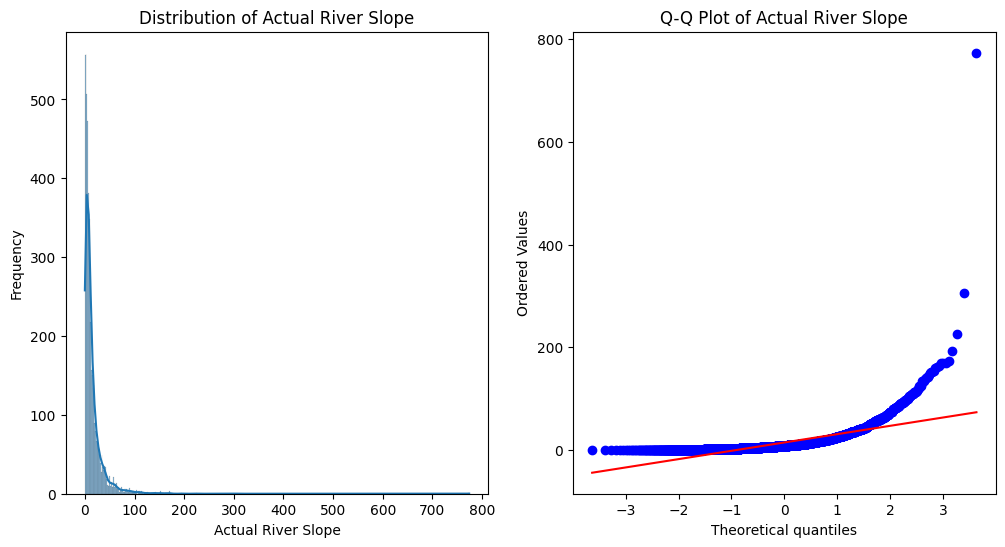


Shapiro-Wilk Test for Actual River Slope:
Test Statistic: 0.5163
P-value: 0.0000
Conclusion: With p-value (0.0000) <= alpha (0.05), we reject the null hypothesis. The data does not appear to be normally distributed.


In [6]:
import numpy as np
from scipy import stats

# 1. Visualization: Histogram and Q-Q plot

# Histogram
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.histplot(df['Actual_river_slope'].dropna(), kde=True)
plt.title('Distribution of Actual River Slope')
plt.xlabel('Actual River Slope')
plt.ylabel('Frequency')

# Q-Q Plot
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
stats.probplot(df['Actual_river_slope'].dropna(), dist="norm", plot=plt)
plt.title('Q-Q Plot of Actual River Slope')
plt.show()

# 2. Hypothesis Testing: Shapiro-Wilk Test
# The Shapiro-Wilk test tests the null hypothesis that the data was drawn from a normal distribution.
# Small p-value (< alpha) leads to rejection of the null hypothesis.

# Drop NaN values for the test
river_slope_data = df['Actual_river_slope'].dropna()

# Perform Shapiro-Wilk test
shapiro_stat, shapiro_p = stats.shapiro(river_slope_data)

print(f"\nShapiro-Wilk Test for Actual River Slope:")
print(f"Test Statistic: {shapiro_stat:.4f}")
print(f"P-value: {shapiro_p:.4f}")

alpha = 0.05
if shapiro_p > alpha:
    print(f"Conclusion: With p-value ({shapiro_p:.4f}) > alpha ({alpha}), we do not reject the null hypothesis. The data appears to be normally distributed.")
else:
    print(f"Conclusion: With p-value ({shapiro_p:.4f}) <= alpha ({alpha}), we reject the null hypothesis. The data does not appear to be normally distributed.")

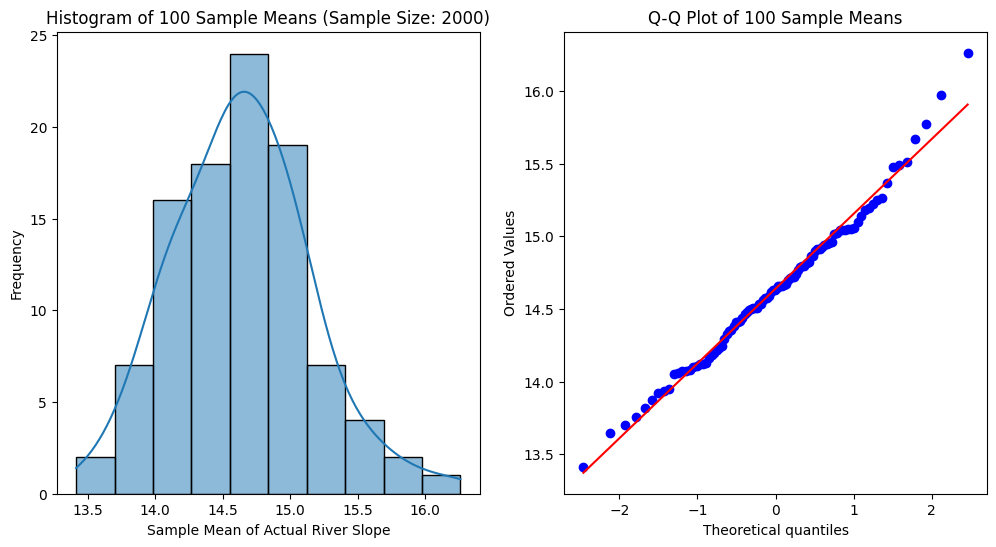


Shapiro-Wilk Test for 100 Sample Means:
Test Statistic: 0.9886
P-value: 0.5549
Conclusion: With p-value (0.5549) > alpha (0.05), we do not reject the null hypothesis. The sample means appear to be normally distributed.


In [7]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure river_slope_data is clean (no NaNs)
river_slope_data_cleaned = df['Actual_river_slope'].dropna()

# Parameters for sampling
num_samples = 100
sample_size = 2000

# Take 100 samples of 2000 observations with replacement and compute the mean for each
sample_means = []
for _ in range(num_samples):
    sample = np.random.choice(river_slope_data_cleaned, size=sample_size, replace=True)
    sample_means.append(np.mean(sample))

# Convert to a pandas Series for easier handling and plotting
sample_means_series = pd.Series(sample_means)

# Plot the resulting histogram of means
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.histplot(sample_means_series, kde=True)
plt.title(f'Histogram of {num_samples} Sample Means (Sample Size: {sample_size})')
plt.xlabel('Sample Mean of Actual River Slope')
plt.ylabel('Frequency')

# Q-Q Plot for the sample means
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
stats.probplot(sample_means_series, dist="norm", plot=plt)
plt.title(f'Q-Q Plot of {num_samples} Sample Means')
plt.show()

# Test if these 100 mean values are drawn from a normal distribution (Shapiro-Wilk Test)
shapiro_stat_means, shapiro_p_means = stats.shapiro(sample_means_series)

print(f"\nShapiro-Wilk Test for {num_samples} Sample Means:")
print(f"Test Statistic: {shapiro_stat_means:.4f}")
print(f"P-value: {shapiro_p_means:.4f}")

alpha = 0.05
if shapiro_p_means > alpha:
    print(f"Conclusion: With p-value ({shapiro_p_means:.4f}) > alpha ({alpha}), we do not reject the null hypothesis. The sample means appear to be normally distributed.")
else:
    print(f"Conclusion: With p-value ({shapiro_p_means:.4f}) <= alpha ({alpha}), we reject the null hypothesis. The sample means do not appear to be normally distributed.")